In [558]:
import pandas as pd
import os
print(os.getcwd())
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
%matplotlib inline
mpl.style.use('ggplot')

/Users/skmishra19/Desktop/AI_ML/Projects_AI:ML/Car_Price_Predictor


In [559]:
df = pd.read_csv('quikr_car.csv')
print(df.head())

   Unnamed: 0.4  Unnamed: 0.3  Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0  \
0             0             0             0             0           0   
1             1             1             1             1           1   
2             2             2             3             3           3   
3             3             3             4             4           4   
4             4             4             6             6           6   

                     name   company  year   Price  kms_driven fuel_type  
0     Hyundai Santro Xing   Hyundai  2007   80000       45000    Petrol  
1     Mahindra Jeep CL550  Mahindra  2006  425000          40    Diesel  
2       Hyundai Grand i10   Hyundai  2014  325000       28000    Petrol  
3  Ford EcoSport Titanium      Ford  2014  575000       36000    Diesel  
4               Ford Figo      Ford  2012  175000       41000    Diesel  


In [560]:
df.shape

(816, 11)

In [561]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0.4  816 non-null    int64 
 1   Unnamed: 0.3  816 non-null    int64 
 2   Unnamed: 0.2  816 non-null    int64 
 3   Unnamed: 0.1  816 non-null    int64 
 4   Unnamed: 0    816 non-null    int64 
 5   name          816 non-null    object
 6   company       816 non-null    object
 7   year          816 non-null    int64 
 8   Price         816 non-null    int64 
 9   kms_driven    816 non-null    int64 
 10  fuel_type     816 non-null    object
dtypes: int64(8), object(3)
memory usage: 70.3+ KB


In [562]:
df.describe()

,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,year,Price,kms_driven
count,816.000000,816.000000,816.000000,816.000000,816.000000,816.000000,8.160000e+02,816.000000
mean,407.500000,408.343137,431.637255,431.637255,431.637255,2012.444853,4.117176e+05,46275.531863
std,235.703203,235.932589,254.197374,254.197374,254.197374,4.002992,4.751844e+05,34297.428044
min,0.000000,0.000000,0.000000,0.000000,0.000000,1995.000000,3.000000e+04,0.000000
25%,203.750000,204.750000,212.750000,212.750000,212.750000,2010.000000,1.750000e+05,27000.000000
50%,407.500000,408.500000,427.500000,427.500000,427.500000,2013.000000,2.999990e+05,41000.000000
75%,611.250000,612.250000,652.250000,652.250000,652.250000,2015.000000,4.912500e+05,56818.500000
max,815.000000,816.000000,889.000000,889.000000,889.000000,2019.000000,8.500003e+06,400000.000000


In [563]:
df['year'].unique()

array([2007, 2006, 2014, 2012, 2013, 2016, 2015, 2010, 2017, 2008, 2018,
       2011, 2019, 2009, 2005, 2000, 2003, 2004, 1995, 2002, 2001])

Quality:-
-> year has many non-year values
-> year object to int

-> Price has 'Ask For Price'
-> Price object to int

-> kms_driven has kms & , with integers
-> kms_driven has nan values

-> fuel_type has nan value

-> keep first 3 words of name



In [564]:
df['Price'].unique()

array([  80000,  425000,  325000,  575000,  175000,  190000,  830000,
        250000,  182000,  315000,  415000,  320000, 1000000,  500000,
        350000,  160000,  310000,   75000,  100000,  290000,   95000,
        180000,  385000,  105000,  650000,  689999,  448000,  549000,
        501000,  489999,  280000,  349999,  284999,  345000,  499999,
        235000,  249999, 1475000,  395000,  220000,  170000,   85000,
        200000,  570000,  110000,  448999, 1891111,  159500,  344999,
        449999,  865000,  699000,  375000,  224999, 1200000,  195000,
        351000,  240000,   90000,  155000,  600000,  189500,  210000,
        390000,  135000, 1600000,  701000,  265000,  525000,  372000,
        635000,  550000,  485000,  329500,  251111,  569999,   69999,
        299999,  399999,  450000,  270000,  158400,  179000,  125000,
        299000,  150000,  285000,  340000,   70000,  289999,  849999,
        749999,  274999,  984999,  599999,  244999,  474999,  245000,
        169500,  275

In [565]:
df['kms_driven'].unique()

array([ 45000,     40,  28000,  36000,  41000,  25000,  24530,  60000,
        30000,  32000,  48660,   4000,  16934,  43000,  35550,  39522,
        39000,  55000,  72000,  15975,  70000,  23452,  35522,  48508,
        15487,  82000,  20000,  68000,  38000,  27000,  33000,  46000,
        16000,  47000,  35000,  30874,  15000,  29685, 130000,  19000,
        54000,  13000,  38200,  22000,  50000,  13500,   3600,  45863,
        60500,  12500,  18000,  13349,  29000,  44000,  42000,  14000,
        49000,  36200,  51000, 104000,  33333,  33600,   5600,   7500,
        24330,  65480, 200000,  59000,  99000,   2800,  21000,  11000,
        66000,   3000,   7000,  38500,  37200,  43200,  24800,  45872,
        40000,  11400,  97200,  52000,  31000, 175430,  37000,  65000,
         3350,  75000,  62000,  73000,   2200,  54870,  34580,  97000,
           60,  80200,   3200,      0,   5000,    588,  71200, 175400,
         9300,  56758,  10000,  56450,  56000,  32700,   9000,     73,
      

In [566]:
df['fuel_type'].unique()

array(['Petrol', 'Diesel', 'LPG'], dtype=object)

Cleaning up the data

In [567]:
backup = df.copy() #copying the dataset to backup variable for future use if needed

In [568]:
df['year']

0      2007
1      2006
2      2014
3      2014
4      2012
       ... 
811    2011
812    2009
813    2009
814    2018
815    2013
Name: year, Length: 816, dtype: int64

In [569]:
# 1. Filter out the non-numeric text values
df = df[df['Price'] != "Ask For Price"]

# 2. Clean commas and convert to integer
df['Price'] = (
    df['Price']
    .astype(str)                   # Ensure it's a string
    .str.replace(',', '', regex=False) # Remove commas
    .str.extract('(\d+)')          # Extract only the digits (just in case)
)

# 3. Final conversion
df['Price'] = pd.to_numeric(df['Price'], errors='coerce').astype(int)

In [570]:
df[df['year'].notnull() & df['year'].astype(str).str.isnumeric()]

,Unnamed: 0.4,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,name,company,year,Price,kms_driven,fuel_type
0,0,0,0,0,0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,1,1,1,1,1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,2,2,3,3,3,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,3,3,4,4,4,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,4,4,6,6,6,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...,...,...,...,...,...
811,811,812,883,883,883,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
812,812,813,885,885,885,Tata Indica V2,Tata,2009,110000,30000,Diesel
813,813,814,886,886,886,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
814,814,815,888,888,888,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [571]:
df['year'] = pd.to_numeric(df['year'], errors='coerce').astype('Int64')

In [572]:
print(df['year'].unique())

<IntegerArray>
[2007, 2006, 2014, 2012, 2013, 2016, 2015, 2010, 2017, 2008, 2018, 2011, 2019,
 2009, 2005, 2000, 2003, 2004, 1995, 2002, 2001]
Length: 21, dtype: Int64


In [573]:
print(df['year'])

0      2007
1      2006
2      2014
3      2014
4      2012
       ... 
811    2011
812    2009
813    2009
814    2018
815    2013
Name: year, Length: 816, dtype: Int64


In [574]:
# 1. Convert to string to ensure .str works, replace commas, then convert to numeric
df['Price'] = pd.to_numeric(df['Price'].astype(str).str.replace(',', '', regex=False), errors='coerce')

# 2. Drop the rows that became NaN (like "Ask for Price")
df = df.dropna(subset=['Price'])

# 3. Convert to integer (since prices usually don't need decimals here)
df['Price'] = df['Price'].astype(int)

In [575]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0.4  816 non-null    int64 
 1   Unnamed: 0.3  816 non-null    int64 
 2   Unnamed: 0.2  816 non-null    int64 
 3   Unnamed: 0.1  816 non-null    int64 
 4   Unnamed: 0    816 non-null    int64 
 5   name          816 non-null    object
 6   company       816 non-null    object
 7   year          816 non-null    Int64 
 8   Price         816 non-null    int64 
 9   kms_driven    816 non-null    int64 
 10  fuel_type     816 non-null    object
dtypes: Int64(1), int64(7), object(3)
memory usage: 71.1+ KB


In [576]:
df['kms_driven'] = pd.to_numeric(
    df['kms_driven'].str.split(' ').str.get(0).str.replace(',', ''),
    errors='coerce'
)

AttributeError: Can only use .str accessor with string values!

In [ ]:
print(df['kms_driven'])

0       45000.0
1          40.0
2       28000.0
3       36000.0
4       41000.0
         ...   
814    132000.0
815     27000.0
816     40000.0
817         NaN
818         NaN
Name: kms_driven, Length: 819, dtype: float64


In [ ]:
df['kms_driven'] = (
    df['kms_driven']
    .astype(str)
    .str.extract(r'(\d[\d,]*)')[0]   # extract numbers like 45,000
    .str.replace(',', '', regex=False)
)

df['kms_driven'] = pd.to_numeric(df['kms_driven'], errors='coerce')

In [ ]:
df['kms_driven'].isnull().sum()

np.int64(2)

In [ ]:
df[~df['fuel_type'].isna()]

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,name,company,year,Price,kms_driven,fuel_type
0,0,0,0,0,Hyundai Santro Xing XO eRLX Euro III,Hyundai,2007,80000,45000.0,Petrol
1,1,1,1,1,Mahindra Jeep CL550 MDI,Mahindra,2006,425000,40.0,Diesel
2,2,3,3,3,Hyundai Grand i10 Magna 1.2 Kappa VTVT,Hyundai,2014,325000,28000.0,Petrol
3,3,4,4,4,Ford EcoSport Titanium 1.5L TDCi,Ford,2014,575000,36000.0,Diesel
4,4,6,6,6,Ford Figo,Ford,2012,175000,41000.0,Diesel
...,...,...,...,...,...,...,...,...,...,...
812,812,883,883,883,Maruti Suzuki Ritz VXI ABS,Maruti,2011,270000,50000.0,Petrol
813,813,885,885,885,Tata Indica V2 DLE BS III,Tata,2009,110000,30000.0,Diesel
814,814,886,886,886,Toyota Corolla Altis,Toyota,2009,300000,132000.0,Petrol
815,815,888,888,888,Tata Zest XM Diesel,Tata,2018,260000,27000.0,Diesel


In [ ]:
df[df['fuel_type'].isna()]

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,name,company,year,Price,kms_driven,fuel_type
128,128,132,132,132,Toyota Corolla,Toyota,2009,275000,26000.0,NaN
817,817,890,890,890,Honda Amaze 1.2 E i VTEC,Honda,2014,180000,NaN,NaN
818,818,891,891,891,Chevrolet Sail 1.2 LT ABS,Chevrolet,2014,160000,NaN,NaN


In [ ]:
df['name'] = df['name'].str.split(' ').str.slice(0, 3).str.join(' ')

In [ ]:
df.reset_index(drop=True, inplace=True)

In [ ]:
df

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,name,company,year,Price,kms_driven,fuel_type
0,0,0,0,0,Hyundai Santro Xing,Hyundai,2007,80000,45000.0,Petrol
1,1,1,1,1,Mahindra Jeep CL550,Mahindra,2006,425000,40.0,Diesel
2,2,3,3,3,Hyundai Grand i10,Hyundai,2014,325000,28000.0,Petrol
3,3,4,4,4,Ford EcoSport Titanium,Ford,2014,575000,36000.0,Diesel
4,4,6,6,6,Ford Figo,Ford,2012,175000,41000.0,Diesel
...,...,...,...,...,...,...,...,...,...,...
814,814,886,886,886,Toyota Corolla Altis,Toyota,2009,300000,132000.0,Petrol
815,815,888,888,888,Tata Zest XM,Tata,2018,260000,27000.0,Diesel
816,816,889,889,889,Mahindra Quanto C8,Mahindra,2013,390000,40000.0,Diesel
817,817,890,890,890,Honda Amaze 1.2,Honda,2014,180000,NaN,NaN


In [ ]:
df.describe()

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,year,Price,kms_driven
count,819.000000,819.000000,819.000000,819.000000,819.0,8.190000e+02,817.000000
mean,409.000000,432.391941,432.391941,432.391941,2012.444444,4.109604e+05,46250.714810
std,236.569229,254.957485,254.957485,254.957485,3.9982,4.744866e+05,34283.745254
min,0.000000,0.000000,0.000000,0.000000,1995.0,3.000000e+04,0.000000
25%,204.500000,212.500000,212.500000,212.500000,2010.0,1.750000e+05,27000.000000
50%,409.000000,428.000000,428.000000,428.000000,2013.0,2.999990e+05,41000.000000
75%,613.500000,653.500000,653.500000,653.500000,2015.0,4.900000e+05,56758.000000
max,818.000000,891.000000,891.000000,891.000000,2019.0,8.500003e+06,400000.000000


In [ ]:
df = df[df['Price']>6e6].reset_index(drop=True)

In [ ]:
df

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,name,company,year,Price,kms_driven,fuel_type
0,535,562,562,562,Mahindra XUV500 W6,Mahindra,2014,8500003,45000.0,Diesel


In [ ]:
df.to_csv('/Users/skmishra19/Desktop/AI_ML/Projects_AI:ML/Car_Price_Predictor/quikr_car.csv', index=False, encoding='utf-8')

Model

In [ ]:
X = df.drop(columns='Price')
y = df['Price'] 

In [ ]:
print(X)

   Unnamed: 0.3  Unnamed: 0.2  Unnamed: 0.1  Unnamed: 0                name  \
0           535           562           562         562  Mahindra XUV500 W6   

    company  year  kms_driven fuel_type  
0  Mahindra  2014     45000.0    Diesel  


In [ ]:
print(y)

0    8500003
Name: Price, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
if len(X) > 1:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
else:
    print("Not enough data to split")

Not enough data to split


In [ ]:
print(df.shape)

(1, 10)


In [ ]:
df['Price'] = df['Price'].astype(str)
df = df[df['Price'].str.contains(r'\d', na=False)]
df['Price'] = pd.to_numeric(df['Price'].str.replace(',', ''), errors='coerce')

df['kms_driven'] = pd.to_numeric(
    df['kms_driven'].astype(str).str.extract(r'(\d+)')[0],
    errors='coerce'
)

df['year'] = pd.to_numeric(df['year'], errors='coerce')

df = df.dropna(subset=['Price', 'kms_driven', 'year'])

print(df.shape)

(1, 10)


In [ ]:
df.head()
df.shape

(1, 10)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_cols = ['name', 'company', 'fuel_type']

ct = ColumnTransformer(
    transformers=[
        ('encoder', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ],
    remainder='passthrough'
)

#X = ct.fit_transform(X)

In [ ]:
lr = LinearRegression()

In [ ]:
pipe = make_pipeline(ct, lr)

In [ ]:
df['company'].unique()

array(['Mahindra'], dtype=object)

In [ ]:
import seaborn as sns

In [ ]:
data = {
    'name': ['Swift', 'i20', 'Baleno', 'Alto'],
    'company': ['Maruti', 'Hyundai', 'Maruti', 'Maruti'],
    'fuel_type': ['Petrol', 'Diesel', 'Petrol', 'Petrol'],
    'year': [2015, 2018, 2017, 2014],
    'kms_driven': [50000, 30000, 40000, 60000],
    'Price': [300000, 500000, 450000, 200000]
}

car = pd.DataFrame(data)

# Features and target
X = car.drop(columns=['Price'])
y = car['Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# Pipeline
categorical_cols = ['name', 'company', 'fuel_type']
numerical_cols = ['year', 'kms_driven']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ]
)

pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Fit
pipe.fit(X_train, y_train)

# Score
print("Model Accuracy:", pipe.score(X_test, y_test))

Model Accuracy: nan


/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:
r2_score(y_test, y_pred)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_regression.py:1288: UndefinedMetricWarning: R^2 score is not well-defined with less than two samples.
  warnings.warn(msg, UndefinedMetricWarning)


nan

Checking relationship of Company with Price

In [ ]:
# Force to string first to avoid AttributeError on re-runs
backup = backup[backup['year'].astype(str).str.isnumeric()]

# Immediately convert to int so it's ready for your ML model
backup['year'] = backup['year'].astype(int)    #year has many non-year values

In [ ]:
backup['year'] = backup['year']     #year is in object. Change to integer

In [ ]:
# 1. Remove non-numeric strings
backup = backup[~backup['Price'].isin(['Ask For Price', 'Call For Price'])]

# 2. Convert to string, remove commas, then to numeric
# Combining these prevents the AttributeError on reruns
backup['Price'] = (
    backup['Price']
    .astype(str)
    .str.replace(',', '', regex=False)
)

# 3. Convert to numeric (coercing errors handles any remaining weird text)
backup['Price'] = pd.to_numeric(backup['Price'], errors='coerce')

# 4. Drop any NaNs and finalize as int
backup = backup.dropna(subset=['Price'])
backup['Price'] = backup['Price'].astype(int)

# Check results
print(backup['Price'].dtype)
print(backup['Price'].head())

int64
0     80000
1    425000
2    325000
3    575000
4    175000
Name: Price, dtype: int64


In [ ]:
# Force the column to string type first, then replace commas
backup['Price'] = backup['Price'].astype(str).str.replace(',', '', regex=False)    #Price has commas in its prices and is in object

In [ ]:
backup['kms_driven']=backup['kms_driven'].str.split().str.get(0).str.replace(',','')      #kms_driven has 'kms driven' in its values. Remove 'kms driven' and commas and convert to numeric

In [ ]:
#It has nan values and two rows have 'Petrol' in them
backup=backup[backup['kms_driven'].str.isnumeric()]
backup['kms_driven']=backup['kms_driven'].astype(int)

In [ ]:
#fuel_type has nan values
backup=backup[~backup['fuel_type'].isna()]
backup.shape

(816, 10)

name and company had spammed data...but with the previous cleaning, those rows got removed.

In [ ]:
#Company does not need any cleaning now. Changing car names. Keeping only the first three words
backup['name']=backup['name'].str.split().str.slice(start=0,stop=3).str.join(' ')

In [ ]:
#Resetting the index of the final cleaned data
backup=backup.reset_index(drop=True)

Cleaned Data

In [ ]:
backup

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,name,company,year,Price,kms_driven,fuel_type
0,0,0,0,0,Hyundai Santro Xing,Hyundai,2007,80000,45000,Petrol
1,1,1,1,1,Mahindra Jeep CL550,Mahindra,2006,425000,40,Diesel
2,2,3,3,3,Hyundai Grand i10,Hyundai,2014,325000,28000,Petrol
3,3,4,4,4,Ford EcoSport Titanium,Ford,2014,575000,36000,Diesel
4,4,6,6,6,Ford Figo,Ford,2012,175000,41000,Diesel
...,...,...,...,...,...,...,...,...,...,...
811,812,883,883,883,Maruti Suzuki Ritz,Maruti,2011,270000,50000,Petrol
812,813,885,885,885,Tata Indica V2,Tata,2009,110000,30000,Diesel
813,814,886,886,886,Toyota Corolla Altis,Toyota,2009,300000,132000,Petrol
814,815,888,888,888,Tata Zest XM,Tata,2018,260000,27000,Diesel


In [ ]:
backup.to_csv('quikr_car.csv')

In [ ]:
backup.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 816 entries, 0 to 815
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Unnamed: 0.3  816 non-null    int64 
 1   Unnamed: 0.2  816 non-null    int64 
 2   Unnamed: 0.1  816 non-null    int64 
 3   Unnamed: 0    816 non-null    int64 
 4   name          816 non-null    object
 5   company       816 non-null    object
 6   year          816 non-null    int64 
 7   Price         816 non-null    object
 8   kms_driven    816 non-null    int64 
 9   fuel_type     816 non-null    object
dtypes: int64(6), object(4)
memory usage: 63.9+ KB


In [ ]:
backup.describe(include='all')

,Unnamed: 0.3,Unnamed: 0.2,Unnamed: 0.1,Unnamed: 0,name,company,year,Price,kms_driven,fuel_type
count,816.000000,816.000000,816.000000,816.000000,816,816,816.000000,816,816.000000,816
unique,NaN,NaN,NaN,NaN,254,25,NaN,272,NaN,3
top,NaN,NaN,NaN,NaN,Maruti Suzuki Swift,Maruti,NaN,250000,NaN,Petrol
freq,NaN,NaN,NaN,NaN,51,221,NaN,16,NaN,428
mean,408.343137,431.637255,431.637255,431.637255,NaN,NaN,2012.444853,NaN,46275.531863,NaN
std,235.932589,254.197374,254.197374,254.197374,NaN,NaN,4.002992,NaN,34297.428044,NaN
min,0.000000,0.000000,0.000000,0.000000,NaN,NaN,1995.000000,NaN,0.000000,NaN
25%,204.750000,212.750000,212.750000,212.750000,NaN,NaN,2010.000000,NaN,27000.000000,NaN
50%,408.500000,427.500000,427.500000,427.500000,NaN,NaN,2013.000000,NaN,41000.000000,NaN
75%,612.250000,652.250000,652.250000,652.250000,NaN,NaN,2015.000000,NaN,56818.500000,NaN


In [ ]:
backup.shape

(816, 10)

Checking relationship of Company with Price

In [ ]:
backup['company'].unique()

array(['Hyundai', 'Mahindra', 'Ford', 'Maruti', 'Skoda', 'Audi', 'Toyota',
       'Renault', 'Honda', 'Datsun', 'Mitsubishi', 'Tata', 'Volkswagen',
       'Chevrolet', 'Mini', 'BMW', 'Nissan', 'Hindustan', 'Fiat', 'Force',
       'Mercedes', 'Land', 'Jaguar', 'Jeep', 'Volvo'], dtype=object)

In [ ]:
import seaborn as sns

In [ ]:
plt.subplots(figsize=(300, 100))
ax=sns.boxplot(x='Price', y='year', data=backup)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

/var/folders/w6/lsw8zz7918vgw7lt1488qvdw0000gn/T/ipykernel_54789/1211135860.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90)


Checking relationship of Year with Price

/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 18.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 14.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 8.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 25.0% of the po

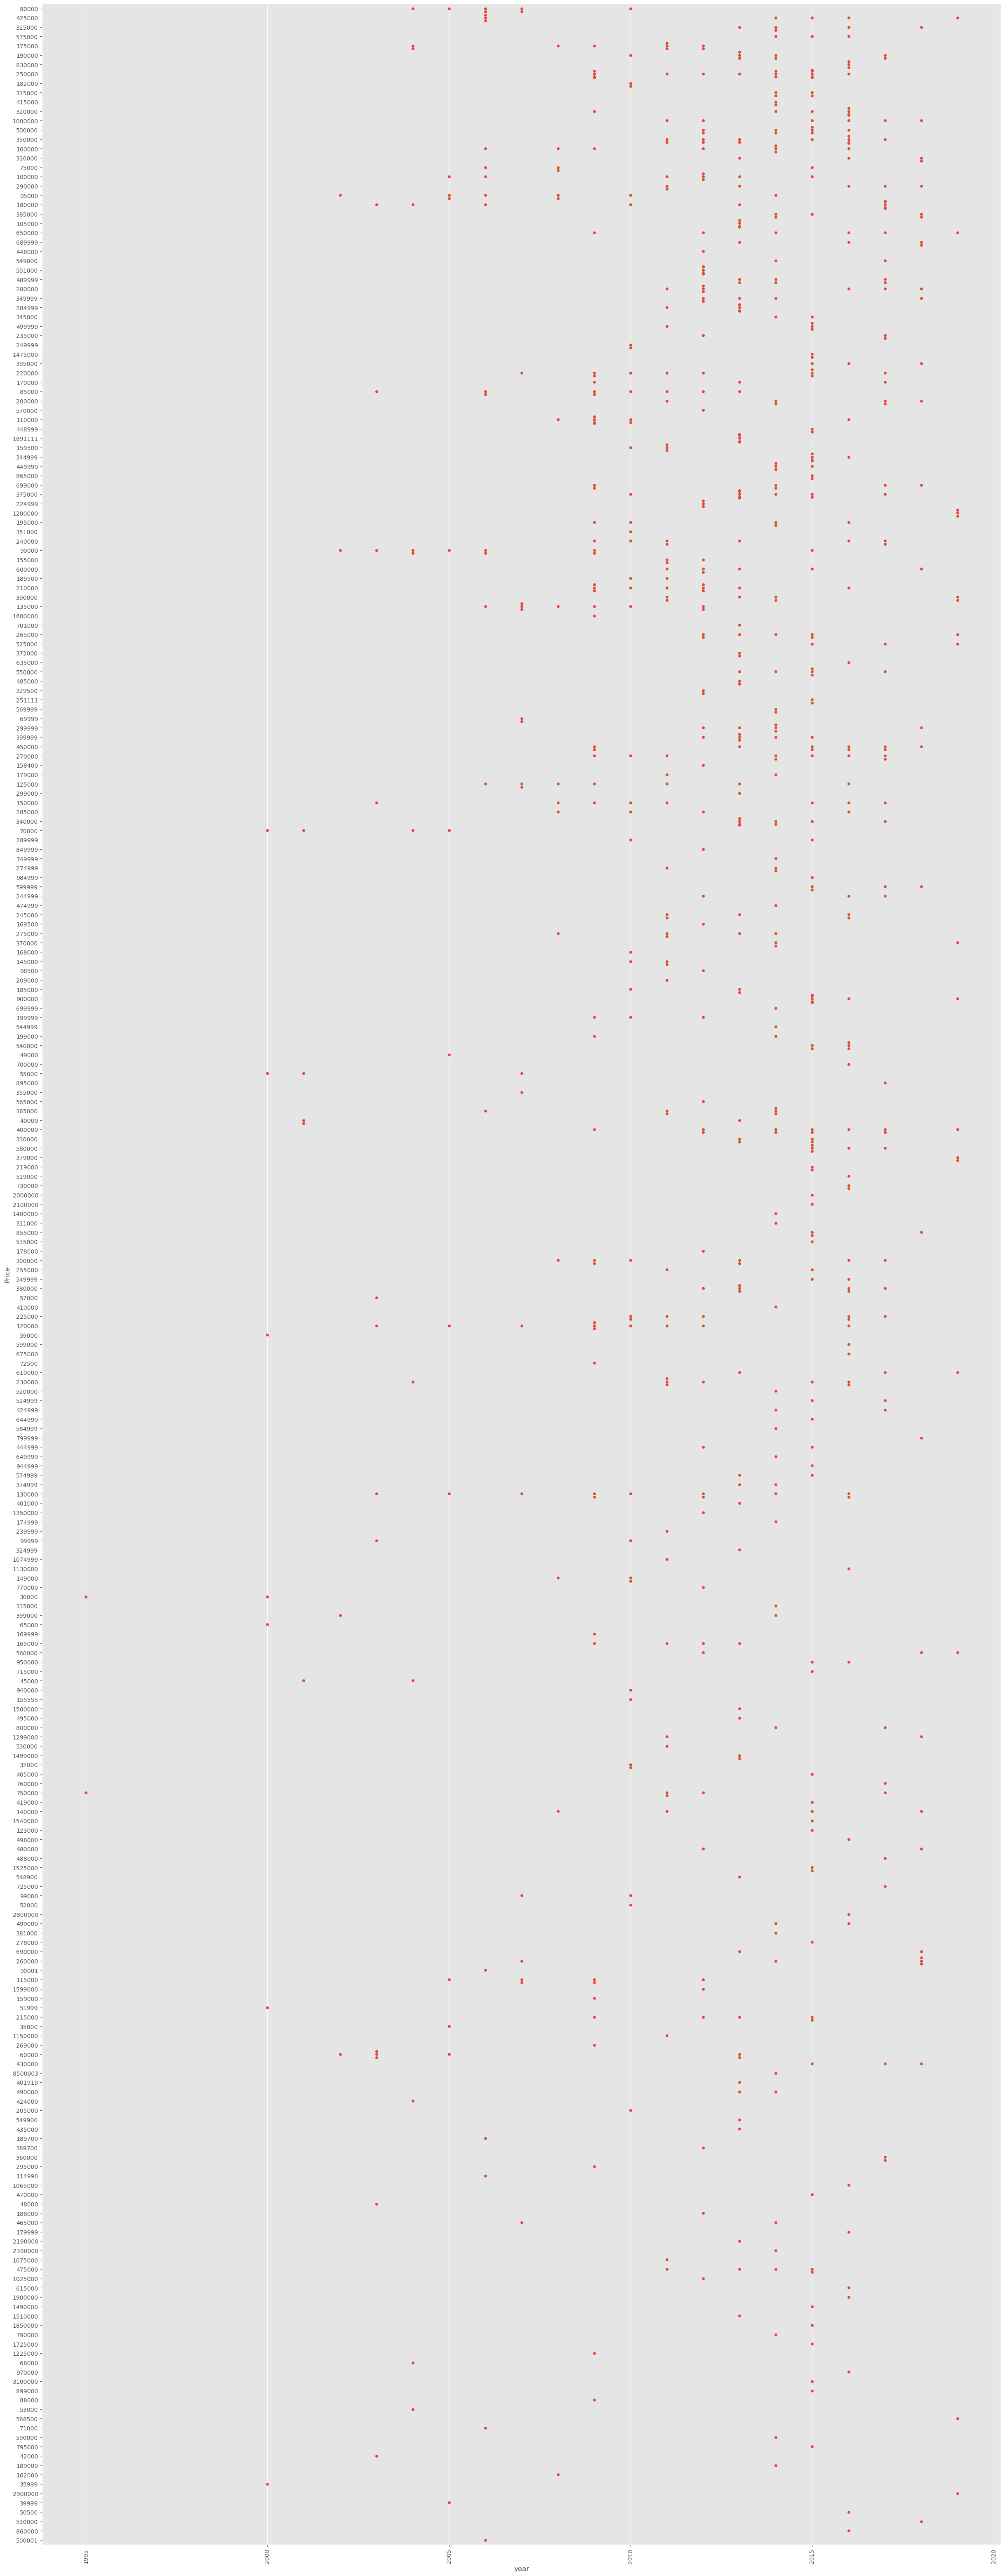

In [ ]:
plt.subplots(figsize=(30, 80))
ax=sns.swarmplot(x='year', y='Price', data=backup)
ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
plt.show()

Checking relationship of kms_driven with Price

In [ ]:
sns.relplot(x='kms_driven',y='Price',data=car,height=7,aspect=1.5)

Checking relationship of Fuel Type with Price

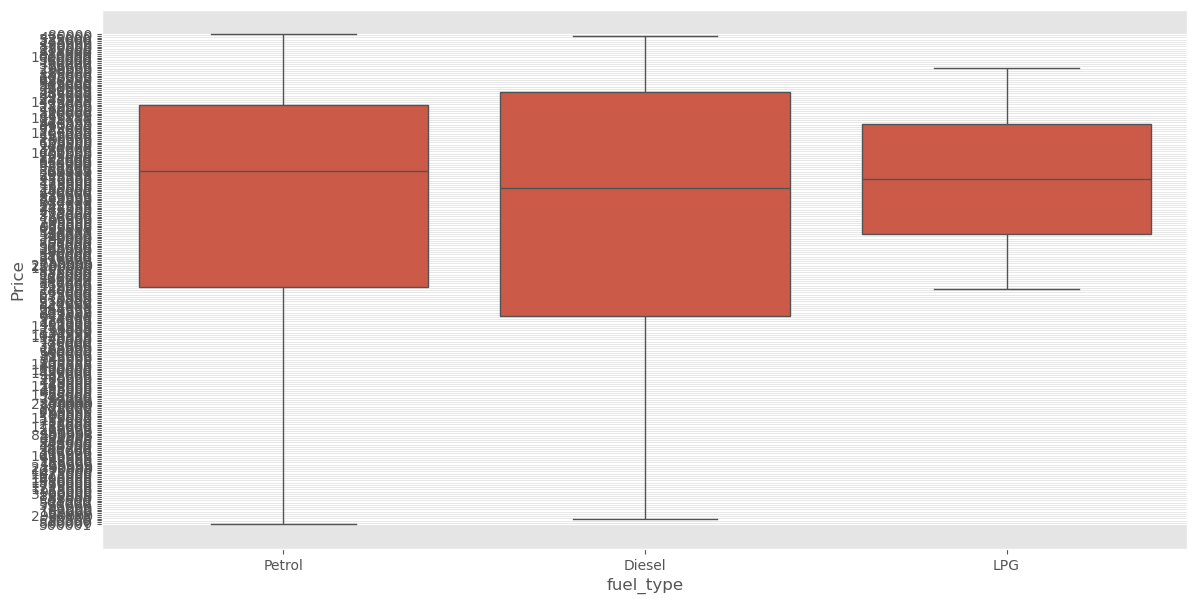

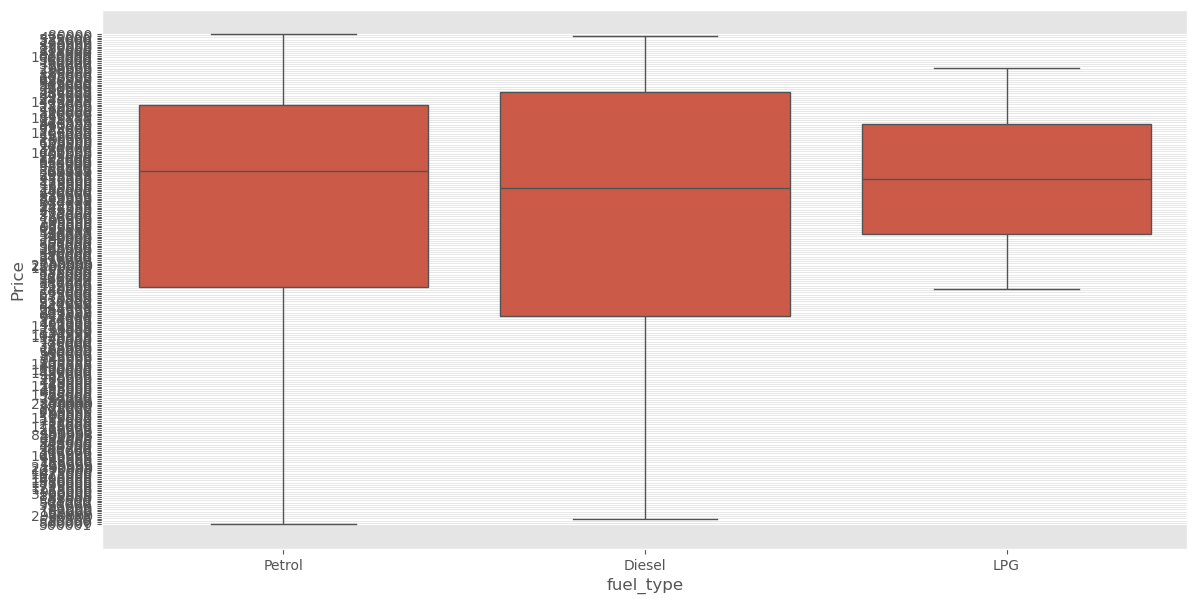

In [ ]:
plt.subplots(figsize=(14, 7))
sns.boxplot(x='fuel_type', y='Price', data=backup)
plt.show()

Relationship of Price with FuelType, Year and Company mixed

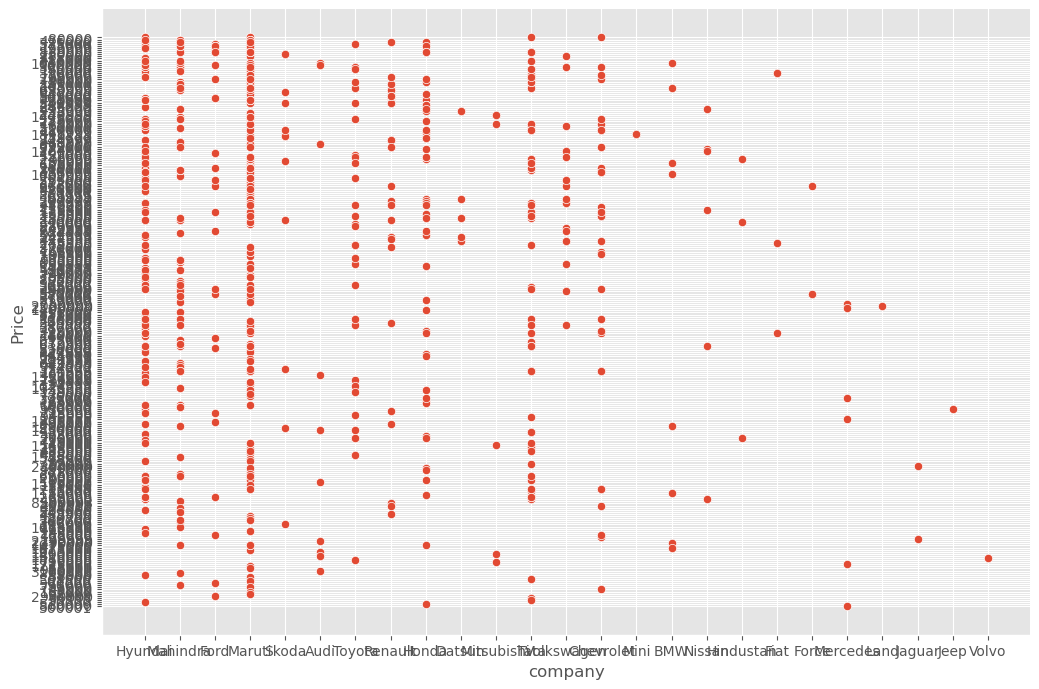

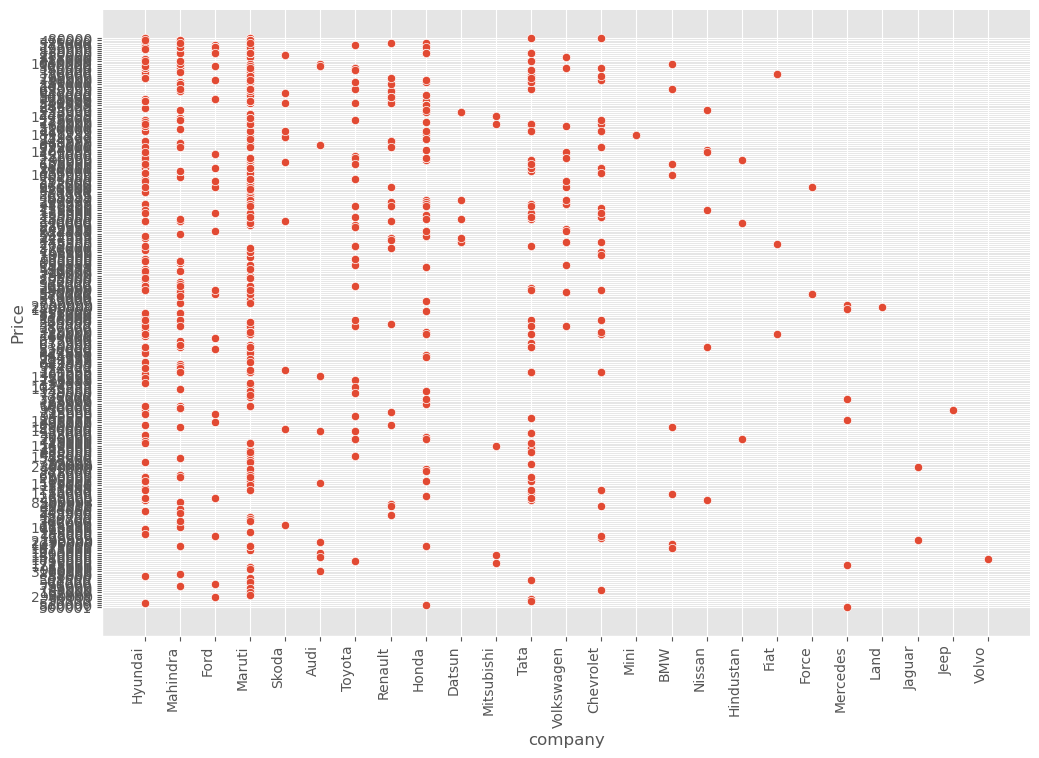

In [ ]:
ax = sns.relplot(x='company', y='Price', data=backup, height=7, aspect=1.5)
ax.set_xticklabels(rotation=90, ha='right')
plt.show()

Extracting Training Data

In [ ]:
X = backup[['name', 'company', 'fuel_type', 'year', 'kms_driven']]
y = backup['Price']

In [ ]:
X

,name,company,fuel_type,year,kms_driven
0,Hyundai Santro Xing,Hyundai,Petrol,2007,45000
1,Mahindra Jeep CL550,Mahindra,Diesel,2006,40
2,Hyundai Grand i10,Hyundai,Petrol,2014,28000
3,Ford EcoSport Titanium,Ford,Diesel,2014,36000
4,Ford Figo,Ford,Diesel,2012,41000
...,...,...,...,...,...
811,Maruti Suzuki Ritz,Maruti,Petrol,2011,50000
812,Tata Indica V2,Tata,Diesel,2009,30000
813,Toyota Corolla Altis,Toyota,Petrol,2009,132000
814,Tata Zest XM,Tata,Diesel,2018,27000


In [ ]:
y.shape

(816,)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score


Creating an OneHotEncoder object to contain all the possible categories

In [ ]:
ohe = OneHotEncoder()
ohe.fit(X[['name', 'company', 'fuel_type']])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'error'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_catego

Creating a column transformer to transform categorical columns


In [ ]:
column_trans = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'), ['name', 'company', 'fuel_type']),
    remainder='passthrough'
)

Linear Regression Model

In [ ]:
lr = LinearRegression()

Making a pipeline

In [ ]:
pipe = make_pipeline(column_trans, lr)

Fitting the model

In [ ]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('columntransformer', ...), ('linearregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoder', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [ ]:
y_prep = pipe.predict(X_test)

Checking R2 Score

In [ ]:
from sklearn.metrics import r2_score

# Predict on test data
y_pred = pipe.predict(X_test)

# Calculate R2 score
r2 = r2_score(y_test, y_pred)

# Print it
print("R2 Score:", r2)

R2 Score: 0.5967999211496828



Finding the model with a random state of TrainTestSplit where the model was found to give almost 0.92 as r2_score

In [ ]:
scores = []
for i in range(1000):
    # 1. Added y_train here
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=i)
    
    lr = LinearRegression()
    pipe = make_pipeline(column_trans, lr)
    
    # 2. Use the y_train we just defined
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    
    # 3. Fixed the typo from y_prep to y_pred
    scores.append(r2_score(y_test, y_pred))

In [ ]:
np.argmax(scores)

np.int64(247)

In [ ]:
scores[np.argmax(scores)]

0.8604058760831599

In [ ]:
import pickle
import pandas as pd

# Load the saved pipeline
model = pickle.load(open('LinearRegressionModel.pkl', 'rb'))

# Predict whenever a user submits a form
result = model.predict(pd.DataFrame(
    columns=['name', 'company', 'year', 'kms_driven', 'fuel_type'],
    data=[['Hyundai Santro Xing', 'Hyundai', 2014, 45000, 'Petrol']]
))
print(result[0])

357645.4811021909



The best model is found at a certain random state

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=np.argmax(scores))
lr=LinearRegression()
pipe=make_pipeline(column_trans, lr)
pipe.fit(X_train, y_train)
y_pred=pipe.predict(X_test)
r2_score(y_test, y_pred)

0.8604058760831599

In [ ]:
import pickle

In [ ]:
pickle.dump(pipe, open('LinearRegressionModel.pkl', 'wb'))

In [ ]:
pipe.predict(pd.DataFrame(columns=['name', 'company', 'year', 'kms_driven', 'fuel_type'], data=[['Hyundai Santro Xing', 'Hyundai', 2014, 45000, 'Petrol']]))

array([289358.84451835])

In [ ]:
pipe.steps[0][1].transformers_[0][1].categories[0]

array(['Audi A3 Cabriolet', 'Audi A4 1.8', 'Audi A4 2.0', 'Audi A6 2.0',
       'Audi A8', 'Audi Q3 2.0', 'Audi Q5 2.0', 'Audi Q7', 'BMW 3 Series',
       'BMW 5 Series', 'BMW 7 Series', 'BMW X1', 'BMW X1 sDrive20d',
       'BMW X1 xDrive20d', 'Chevrolet Beat', 'Chevrolet Beat Diesel',
       'Chevrolet Beat LS', 'Chevrolet Beat LT', 'Chevrolet Beat PS',
       'Chevrolet Cruze LTZ', 'Chevrolet Enjoy', 'Chevrolet Enjoy 1.4',
       'Chevrolet Sail 1.2', 'Chevrolet Sail UVA', 'Chevrolet Spark',
       'Chevrolet Spark 1.0', 'Chevrolet Spark LS', 'Chevrolet Spark LT',
       'Chevrolet Tavera LS', 'Chevrolet Tavera Neo', 'Datsun GO T',
       'Datsun Go Plus', 'Datsun Redi GO', 'Fiat Linea Emotion',
       'Fiat Petra ELX', 'Fiat Punto Emotion', 'Force Motors Force',
       'Force Motors One', 'Ford EcoSport', 'Ford EcoSport Ambiente',
       'Ford EcoSport Titanium', 'Ford EcoSport Trend',
       'Ford Endeavor 4x4', 'Ford Fiesta', 'Ford Fiesta SXi', 'Ford Figo',
       'Ford Figo Diese